In [1]:
# ...existing code...
import joblib
from pathlib import Path
import subprocess, sys

try:
    ROOT = Path(subprocess.check_output(["git","rev-parse","--show-toplevel"], text=True).strip())
except Exception:
    ROOT = Path.cwd().resolve().parent  # experiments/ -> repo root

# Make repo packages (e.g., `pipeline`) importable for unpickling
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# (optional) pre-import the class’ module used in the pickle
# from pipeline.algo1 import Algo1Outputs

artifact = ROOT / "outputs" / "artifacts" / "algo1_outs_2025-05-22_1min_agreg.pkl"
outs = joblib.load(artifact)
print("Loaded:", artifact)

Loaded: /Users/167011/Documents/GitHub/deribit_market_model/outputs/artifacts/algo1_outs_2025-05-22_1min_agreg.pkl


Loaded: /Users/167011/Documents/GitHub/deribit_market_model/outputs/artifacts/algo1_outs_2025-05-22_1min_agreg.pkl


100%|██████████| 338/338 [00:00<00:00, 31497.58it/s]

Epoch 1/600  Train NLL: -7.1874e+00  Test NLL: -7.2766e+00
Epoch 2/600  Train NLL: -7.2655e+00  Test NLL: -7.3549e+00
Epoch 3/600  Train NLL: -7.3438e+00  Test NLL: -7.4333e+00
Epoch 4/600  Train NLL: -7.4222e+00  Test NLL: -7.5119e+00
Epoch 5/600  Train NLL: -7.5008e+00  Test NLL: -7.5905e+00
Epoch 6/600  Train NLL: -7.5795e+00  Test NLL: -7.6693e+00
Epoch 7/600  Train NLL: -7.6583e+00  Test NLL: -7.7483e+00
Epoch 8/600  Train NLL: -7.7373e+00  Test NLL: -7.8274e+00
Epoch 9/600  Train NLL: -7.8165e+00  Test NLL: -7.9067e+00


Epoch 10/600  Train NLL: -7.8958e+00  Test NLL: -7.9862e+00
Epoch 11/600  Train NLL: -7.9753e+00  Test NLL: -8.0658e+00
Epoch 12/600  Train NLL: -8.0549e+00  Test NLL: -8.1456e+00
Epoch 13/600  Train NLL: -8.1347e+00  Test NLL: -8.2255e+00
Epoch 14/600  Train NLL: -8.2146e+00  Test NLL: -8.3056e+00
Epoch 15/600  Train NLL: -8.2947e+00  Test NLL: -8.3858e+00
Epoch 16/600  Train NLL: -8.3750e+00  Test NLL: -8.4663e+00
Epoch 17/600  Train NLL: -8.4555e+00  Test NLL: -8.5468e+00
Epoch 18/600  Train NLL: -8.5361e+00  Test NLL: -8.6276e+00
Epoch 19/600  Train NLL: -8.6169e+00  Test NLL: -8.7086e+00
Epoch 20/600  Train NLL: -8.6979e+00  Test NLL: -8.7897e+00
Epoch 21/600  Train NLL: -8.7791e+00  Test NLL: -8.8709e+00
Epoch 22/600  Train NLL: -8.8605e+00  Test NLL: -8.9525e+00
Epoch 23/600  Train NLL: -8.9420e+00  Test NLL: -9.0342e+00
Epoch 24/600  Train NLL: -9.0237e+00  Test NLL: -9.1161e+00
Epoch 25/600  Train NLL: -9.1056e+00  Test NLL: -9.1983e+00
Epoch 26/600  Train NLL: -9.1878e+00  Te

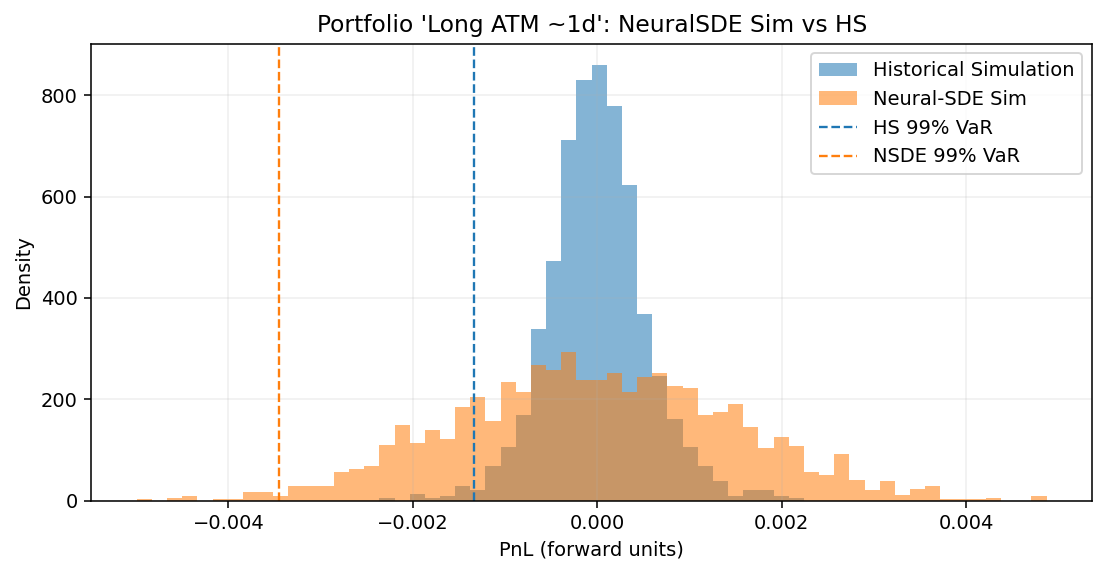

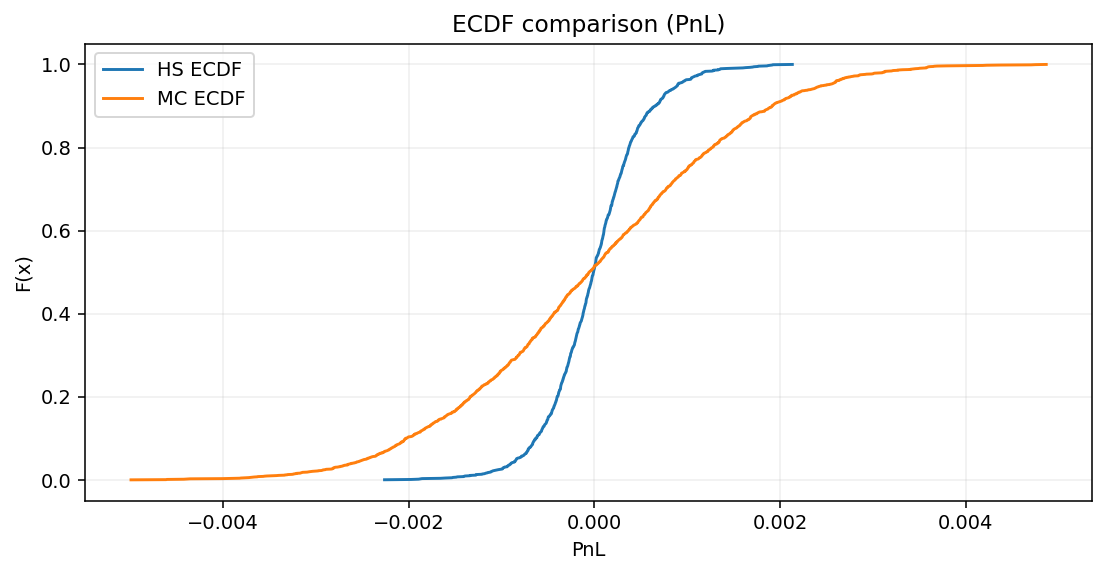

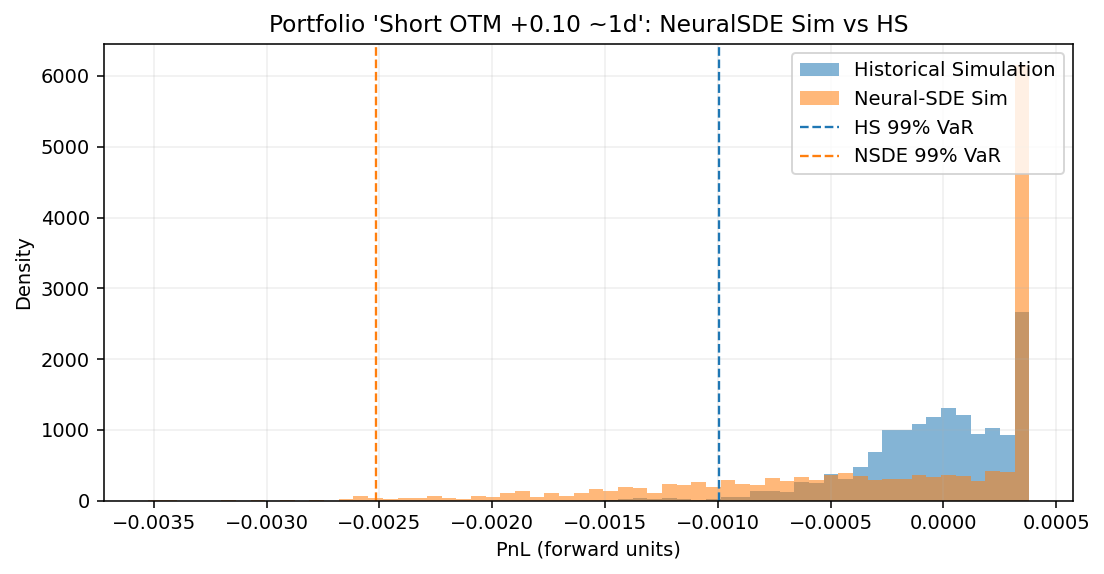

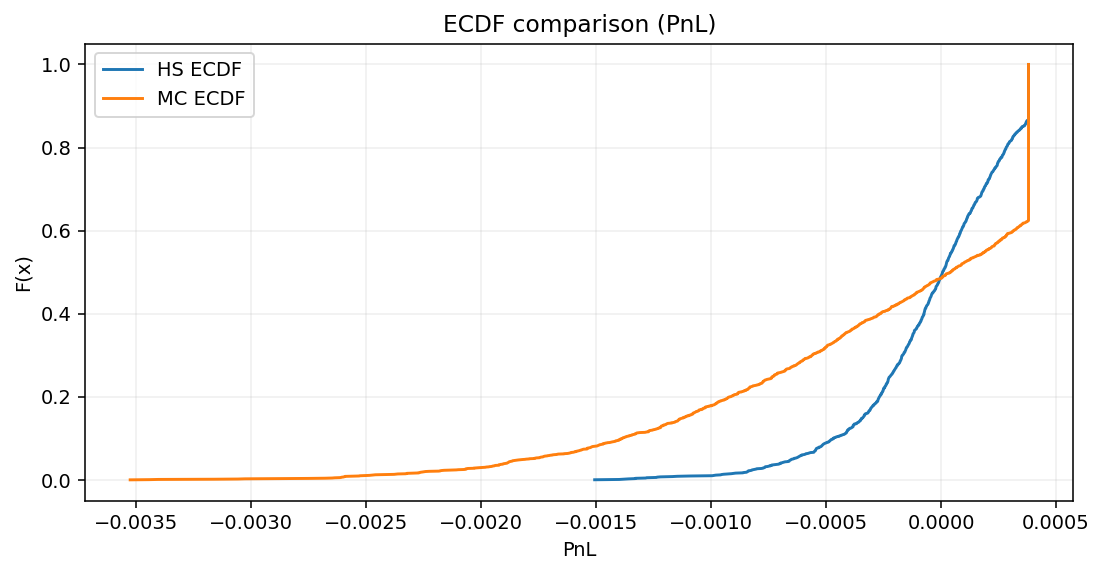

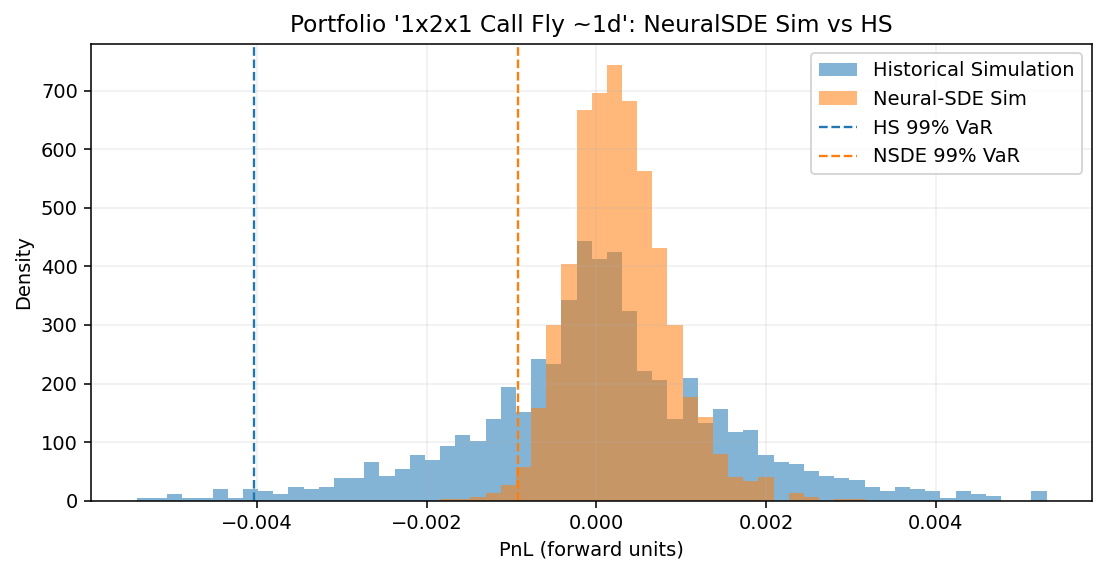

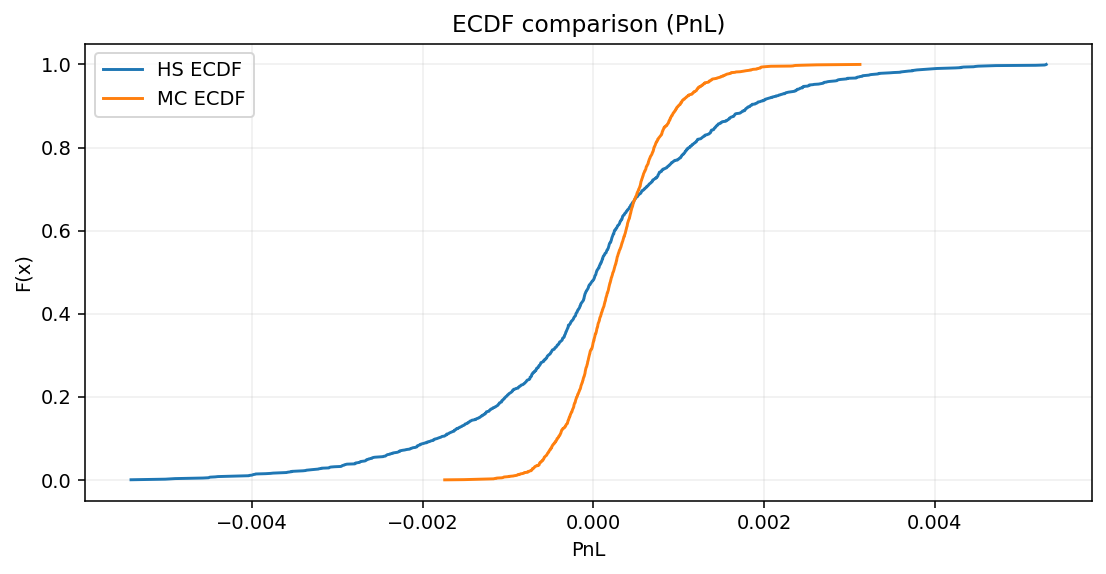

Done.


In [4]:
# End-to-end MC vs HS simulation using the trained Neural-SDE and the decoded lattice/factors.

import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import torch
import matplotlib.pyplot as plt

# --- repo imports (ensure repo root on sys.path) ---
try:
    ROOT = Path(
        __import__("subprocess").check_output(["git","rev-parse","--show-toplevel"], text=True).strip()
    )
except Exception:
    ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from neural_sde.loss import (
    likelihood_training,                      # -> [neural_sde/loss.py]
    build_xi_training_data                    # -> [neural_sde/loss.py]
)
from neural_sde.constraints import (
    compute_factor_polytope_vertices,
    assemble_Wb_for_shrinkage,
    build_factor_path,
    calc_diffusion_scaling,
    shrink_matrix_and_diag,
    shrink_diag_covmatch,
    normalise_dist_diffusion,          # <-- add
    normalise_dist_drift,              # <-- add
    calc_drift_correction, 
    _apply_boundary_correction            # <-- add
)
# Factors -> prices helpers exist in factors.decode but we reimplement here for clarity
# (same algebra as [`factors.decode.reconstruct_prices`](factors/decode.py))

plt.rcParams["figure.dpi"] = 140

# ----------------------------
# 0) Load decoding artifact
# ----------------------------
def load_outs(artifact: Path):
    outs = joblib.load(artifact)
    print("Loaded:", artifact)
    return outs

# ----------------------------
# 1) Shrink geometry + training
# ----------------------------
def train_neural_sde_with_shrink(outs, *, epochs=500, batch=256, lr=5e-5, zero_drift=False):
    # Polytope geometry
    poly = compute_factor_polytope_vertices(outs, xi_builder=None, k_box=6.0, verbose=False, return_mappings=True)
    W, b = assemble_Wb_for_shrinkage(poly, include_box=True)

    # Factor path X and diffs dX (train)
    X  = build_factor_path(outs, xi_builder=None)      # (T, p)  order = dyn|stat|sa
    dX = np.diff(X, axis=0)
    X  = X[:-1]                                        # align to dX

    # Calibrate shrinkage intensity so that projection “epsilon/proj_scale” hits ~0.95
    frac_critical_threshold = 0.9
    critical_value = 0.95
    proj_scale = 0.9

    dist_X = np.abs(W @ X.T - b[:, None])              # (n_faces, T)
    per_face_max = np.max(dist_X, axis=1)              # (n_faces,)
    critical_threshold = frac_critical_threshold * np.min(per_face_max)
    dist_multiplier = (1.0/(1.0 - critical_value) - 1.0) / max(critical_threshold, 1e-12)

    Omegas, det_Omega, proj_dX = calc_diffusion_scaling(
        W=W, b=b, X=X, dX=dX, dist_multiplier=dist_multiplier, proj_scale=proj_scale
    )

    # Same for test to monitor generalization
    _, X_te, _ = build_xi_training_data(outs)
    dX_te = np.diff(X_te, axis=0); X_te = X_te[:-1]
    Omegas_te, det_Omega_te, proj_dX_te = calc_diffusion_scaling(
        W=W, b=b, X=X_te, dX=dX_te, dist_multiplier=dist_multiplier, proj_scale=proj_scale
    )

    # Train Neural-SDE one-step likelihood with supplied shrink stats
    train_losses, test_losses, model, X_train = likelihood_training(
        outs,
        Omega_tr=Omegas,           det_Omega_tr=det_Omega,   proj_dX_tr=proj_dX,
        Omega_te=Omegas_te,        det_Omega_te=det_Omega_te, proj_dX_te=proj_dX_te,
        n_epochs=epochs, batch_size=batch, lr=lr, data="xi", zero_drift=zero_drift, model=None
    )
    print("Training done. Final train/test NLL:", train_losses[-1], test_losses[-1])
    return model

# ----------------------------
# 2) Factors -> prices mapping
# ----------------------------
def split_blocks_factory(outs):
    k_dyn  = outs.G_dyn.shape[0] if getattr(outs, "G_dyn", None) is not None and outs.G_dyn.size else 0
    k_stat = outs.G_stat.shape[0] if getattr(outs, "G_stat", None) is not None and outs.G_stat.size else 0
    k_sa   = outs.G_sa.shape[0]   if getattr(outs, "G_sa",   None) is not None and outs.G_sa.size   else 0
    def split_blocks(x):
        i=0
        xd = x[..., i:i+k_dyn];  i += k_dyn
        xs = x[..., i:i+k_stat]; i += k_stat
        xa = x[..., i:i+k_sa] if k_sa>0 else x[..., :0]
        return xd, xs, xa
    return split_blocks, k_dyn, k_stat, k_sa

def factors_to_prices_factory(outs):
    split_blocks, k_dyn, k_stat, k_sa = split_blocks_factory(outs)
    N  = outs.G0.shape[0]
    G0 = outs.G0.astype(np.float64)
    Gd = outs.G_dyn.astype(np.float64) if k_dyn>0 else np.zeros((0, N))
    Gs = outs.G_stat.astype(np.float64) if k_stat>0 else np.zeros((0, N))
    Ga = outs.G_sa.astype(np.float64)   if k_sa>0   else np.zeros((0, N))
    m = outs.nodes_sub[:, 1].astype(np.float64)
    lb = np.maximum(1.0 - np.exp(m), 0.0)  # lower no‑arb bound

    def factors_to_prices(X):
        B, T1, _ = X.shape
        C = np.empty((B, T1, N), dtype=np.float64)
        for t in range(T1):
            xd,xs,xa = split_blocks(X[:, t, :])
            term = np.broadcast_to(G0, (B, N)).copy()
            if k_dyn:  term += xd @ Gd
            if k_stat: term += xs @ Gs
            if k_sa:   term += xa @ Ga
            C[:, t, :] = term
        return np.clip(C, lb[None, None, :], 1.0)

    return factors_to_prices

# ----------------------------
# 3) One-step and multi-step MC
# ----------------------------
@torch.no_grad()
def simulate_factors_mc_shrunk(
    model, x0_raw, *,
    n_steps=1, n_paths=512, dt_seconds=60.0,
    W=None, b=None, X_interior=None,
    dist_multiplier=1.0, proj_scale=0.9,
    rho_star=1e-5, epsmu_star=10.0,
    s_floor=0.5, s_ceil=1.0, bc_cap=5.0,
    clamp_sig=1e-9,
    to_model=lambda x: x, from_model=lambda x: x
):
    """
    EM with diagonal diffusion as learned, but:
      - shrink diag σ by geometry-aware multipliers s in [s_floor, s_ceil]
      - correct drift with inward face-based BC (masked to inward faces)
    """
    assert W is not None and b is not None and X_interior is not None
    device = next(model.parameters()).device
    x0 = to_model(x0_raw.astype(np.float64))
    x  = torch.from_numpy(np.tile(x0, (n_paths, 1))).float().to(device)
    DT  = torch.tensor(float(dt_seconds), dtype=torch.float32, device=device).view(1,1)
    sDT = torch.sqrt(DT)
    out = [x.clone()]

    p = x0_raw.shape[0]
    W_np, b_np, Xin_np = np.asarray(W), np.asarray(b), np.asarray(X_interior)

    for _ in range(n_steps):
        mu  = model.f(0.0, x)                         # (B,p)
        sig = model.g(0.0, x).clamp_min(clamp_sig)    # (B,p)
        mu_np  = mu.detach().cpu().numpy()
        sig_np = sig.detach().cpu().numpy()

        # step per path (kept simple/robust)
        x_np = from_model(x.detach().cpu().numpy())   # model -> raw Xi for geometry
        x_next = np.empty_like(x_np)

        for bidx in range(n_paths):
            x_cur = x_np[bidx]            # (p,)
            mu_t  = mu_np[bidx]           # (p,)
            sig_t = sig_np[bidx]          # (p,)

            # --- diffusion shrinkage (cov-match; pick p closest faces)
            rho = np.abs(W_np @ x_cur - b_np) / (np.linalg.norm(W_np, axis=1) + 1e-12)
            eps_sigma = normalise_dist_diffusion(rho, dist_multiplier, proj_scale)  # (m,)
            idx = np.argsort(eps_sigma)[:p]
            Wd = W_np[idx, :]
            eps_sel = np.maximum(eps_sigma[idx], 1e-6)

            # Q from QR of Wd.T (orthonormal cols)
            Q = np.linalg.qr(Wd.T)[0]                     # (p,p)
            P = Q @ np.diag(eps_sel) @ Q.T                # (p,p)

            s = shrink_diag_covmatch(
                    torch.from_numpy(P[None]).float(),
                    torch.from_numpy(sig_t[None]).float()
                ).squeeze(0).cpu().numpy()                # (p,)
            s = np.clip(s, s_floor, s_ceil)

            # --- drift correction (mask to inward faces; per-dim clip)
            eps_mu = normalise_dist_drift(rho, rho_star, epsmu_star)   # (m,)
            muW = W_np @ mu_t                                         # (m,)
            corr_dirs = (Xin_np - x_cur[None, :])                      # (m,p)
            denom = (corr_dirs * W_np).sum(axis=1)                     # (m,)

            need   = (-muW - eps_mu) > 0.0
            inward = denom > 1e-12
            mask   = need & inward

            delta_mu = np.zeros_like(mu_t)
            if np.any(mask):
                wts = (-muW[mask] - eps_mu[mask]) / denom[mask]
                delta_mu = (wts[:, None] * corr_dirs[mask]).sum(axis=0)
                delta_mu = np.clip(delta_mu, -bc_cap, bc_cap)

            mu_corr = mu_t + delta_mu

            # --- one EM step (in raw Xi), then return to model space for next net eval
            eps = np.random.normal(size=p)
            x1_raw = x_cur + mu_corr*float(dt_seconds) + (s*sig_t)*np.sqrt(float(dt_seconds))*eps
            x_next[bidx] = x1_raw

        # push x_next to model space and continue
        x = torch.from_numpy(to_model(x_next)).float().to(device)
        out.append(x.clone())

    X_mod = torch.stack(out, dim=1).cpu().numpy()           # (B, T+1, p) in model space
    X_raw = from_model(X_mod)                                # -> raw Xi
    return X_raw

# @torch.no_grad()
# def simulate_factors_mc_shrunk(
#     model, x0_raw, *,
#     n_steps=1, n_paths=512, dt_seconds=60.0,
#     H=None, h=None,                 # <-- pass H,h for shrink
#     corr_dirs=None, epsmu=None,     # <-- pass tensors from calc_drift_correction
#     t_idx_global=None,              # <-- index of x0 on the reference path
#     clamp_sig=1e-9,
#     to_model=lambda x: x, from_model=lambda x: x
# ):
#     assert H is not None and h is not None, "need (H,h) for shrink"
#     device = next(model.parameters()).device
#     torch_dtype = torch.float32

#     x0 = to_model(x0_raw.astype(np.float64))
#     x  = torch.from_numpy(np.tile(x0, (n_paths, 1))).to(device=device, dtype=torch_dtype)
#     DT = torch.tensor(float(dt_seconds), dtype=torch_dtype, device=device).view(1, 1)
#     out = [x.clone()]

#     H_t = torch.from_numpy(np.asarray(H)).to(device=device, dtype=torch_dtype)
#     h_t = torch.from_numpy(np.asarray(h)).to(device=device, dtype=torch_dtype)

#     for _ in range(n_steps):
#         mu  = model.f(0.0, x)                          # (B,p)
#         sig = model.g(0.0, x).clamp_min(clamp_sig)     # (B,p)

#         # Drift boundary correction (same as training)
#         if (corr_dirs is not None) and (epsmu is not None) and (t_idx_global is not None):
#             t_idx = torch.full((x.size(0),), int(t_idx_global), dtype=torch.long, device=device)
#             mu = _apply_boundary_correction(
#                 mu, t_idx, corr_dirs=corr_dirs, epsmu=epsmu,
#                 bc_lambda=1.0, bc_eps_floor=1e-8, bc_cap=None, bc_epsmu_cutoff=None, device=device
#             )

#         # Diffusion shrinkage (same geometry as training)
#         P_mat = shrink_matrix_and_diag(x, H_t, h_t, mode="matrix")   # (B,p,p)
#         s     = shrink_diag_covmatch(P_mat, sig)                     # (B,p)
#         sig   = s * sig

#         eps = torch.randn_like(x)
#         x   = x + mu*DT + sig*torch.sqrt(DT)*eps
#         out.append(x.clone())

#     X_mod = torch.stack(out, dim=1).cpu().numpy()
#     return from_model(X_mod)  # raw Xi

# ----------------------------
# 4) Historical Simulation (HS) in factor space
# ----------------------------
def build_hs_from_factors(outs, x0_raw):
    Xi_tr, Xi_te, _ = build_xi_training_data(outs)
    Xi_hist = np.vstack([Xi_tr, Xi_te])
    dXi = Xi_hist[1:] - Xi_hist[:-1]              # (M, p)
    B = dXi.shape[0]
    X_seq = np.stack([np.tile(x0_raw, (B,1)), x0_raw[None,:] + dXi], axis=1)   # (B,2,p)
    return X_seq

# ----------------------------
# 5) Portfolio utils
# ----------------------------
def nearest_node_index(tau, m, nodes):
    diffs = nodes - np.array([tau, m])[None, :]
    return int(np.argmin(np.sum(diffs*diffs, axis=1)))

def make_q_from_spec(spec, nodes):
    N = nodes.shape[0]
    q = np.zeros(N, dtype=float)
    if isinstance(spec, dict):
        for j, qty in spec.items():
            q[int(j)] += float(qty)
        return q
    for tau, m, qty in spec:
        j = nearest_node_index(float(tau), float(m), nodes)
        q[j] += float(qty)
    return q

def portfolio_pnl_from_c(C_sim, q, F_path=None, multipliers=None):
    C_sim = np.asarray(C_sim); q = np.asarray(q).reshape(-1)
    B, T1, N = C_sim.shape
    w = np.ones(N) if multipliers is None else np.asarray(multipliers).reshape(-1)
    notional = q * w
    V = C_sim @ notional                        # (B, T+1) forward-units
    V = V * (1.0 if F_path is None else F_path)
    return V[:, -1] - V[:, 0]

def overlay_returns_histograms(C_sim_MC, C_sim_HS, q, title="Portfolio return distribution: MC vs HS"):
    x_MC = portfolio_pnl_from_c(C_sim_MC, q)
    x_HS = portfolio_pnl_from_c(C_sim_HS, q)
    x_MC = x_MC[np.isfinite(x_MC)]
    x_HS = x_HS[np.isfinite(x_HS)]
    lo = np.min([x_MC.min(), x_HS.min()]); hi = np.max([x_MC.max(), x_HS.max()])
    edges = np.linspace(lo, hi, 60+1)

    plt.figure(figsize=(8,4.2))
    plt.hist(x_HS, bins=edges, density=True, alpha=0.55, label="Historical Simulation")
    plt.hist(x_MC, bins=edges, density=True, alpha=0.55, label="Neural‑SDE Sim")
    plt.axvline(np.quantile(x_HS, 0.01), color="C0", ls="--", lw=1.2, label="HS 99% VaR")
    plt.axvline(np.quantile(x_MC, 0.01), color="C1", ls="--", lw=1.2, label="NSDE 99% VaR")
    plt.title(title); plt.xlabel("PnL (forward units)"); plt.ylabel("Density")
    plt.grid(alpha=0.2); plt.legend(); plt.tight_layout(); plt.show()

    # ECDF
    def ecdf(x): xs = np.sort(x); ys = np.arange(1,len(x)+1)/len(x); return xs, ys
    xs_HS,F_HS = ecdf(x_HS); xs_MC,F_MC = ecdf(x_MC)
    plt.figure(figsize=(8,4.2))
    plt.plot(xs_HS, F_HS, label="HS ECDF"); plt.plot(xs_MC, F_MC, label="MC ECDF")
    plt.title("ECDF comparison (PnL)"); plt.xlabel("PnL"); plt.ylabel("F(x)")
    plt.grid(alpha=0.2); plt.legend(); plt.tight_layout(); plt.show()

# ----------------------------
# 6) Main
# ----------------------------
def main():
    # 0) inputs
    artifact = ROOT / "outputs" / "artifacts" / "algo1_outs_2025-05-22_1min_agreg.pkl"
    outs = load_outs(artifact)

    # 1) train SDE (or replace with a previously trained model)
    model = train_neural_sde_with_shrink(outs, epochs=600, batch=256, lr=5e-5, zero_drift=True)
    device = next(model.parameters()).device
    print("Model device:", device)

    # 2) time step scaling: SECONDS (consistent with training and validation code)
    sec_per_year = 1
    tt_tr = pd.to_datetime(outs.C_train.index.values)
    dt_tr = dt_tr = (tt_tr[1:] - tt_tr[:-1]).to_numpy(dtype="timedelta64[s]").astype(np.float64) / sec_per_year
    dt_seconds = float(np.median(dt_tr)) if len(dt_tr) else 60.0
    print("Median dt (seconds):", dt_seconds)

    # 3) start state x0 (use last observed test state if available for apples-to-apples)
    Xi_tr, Xi_te, _ = build_xi_training_data(outs)
    x0_raw = (Xi_te[-1] if len(Xi_te) else Xi_tr[-1]).astype(np.float64)
    # 3a) polytope (W,b)
    poly = compute_factor_polytope_vertices(outs, xi_builder=None, k_box=6.0, verbose=False, return_mappings=True)
    W, b = assemble_Wb_for_shrinkage(poly, include_box = True)
    H, h = poly['H'], poly['h']

    # 3b) Calibrate dist_multiplier (same scheme you used in training helper)
    X_all = build_factor_path(outs, xi_builder=None)        # (T, p)
    dist = np.abs(W @ X_all.T - b[:, None])                 # (m, T)
    per_face_max = np.max(dist, axis=1)
    frac_critical_threshold = 0.9
    critical_value = 0.95
    proj_scale = 0.9
    critical_threshold = frac_critical_threshold * float(np.min(per_face_max))
    dist_multiplier = (1.0/(1.0 - critical_value) - 1.0) / max(critical_threshold, 1e-12)

    # 3c) Precompute interior anchors for BC once (use test factors as reference)
    X_ref = np.vstack([Xi_tr, Xi_te]) if len(Xi_te) else Xi_tr
    X_interior, corr_dirs_flat, epsmu = calc_drift_correction(W, b, X_ref, rho_star=1e-5, epsmu_star=10.0, tol_face=1e-6)
    t_idx_global = X_ref.shape[0] - 1

    # 4) Monte‑Carlo: one-step to compare to HS
    X_mc = simulate_factors_mc_shrunk(
        model, x0_raw,
        n_steps=1, n_paths=2048, dt_seconds=dt_seconds,
        W=W, b=b, X_interior=X_interior,
        dist_multiplier=dist_multiplier, proj_scale=proj_scale,
        rho_star=1e-5, epsmu_star=10.0,
        s_floor=0.2, s_ceil=1.0, bc_cap=5.0,
        clamp_sig=1e-9,
        to_model=lambda x: x, from_model=lambda x: x
    )
#     X_mc = simulate_factors_mc_shrunk(
#     model, x0_raw,
#     n_steps=1, n_paths=2048, dt_seconds=dt_seconds,
#     H=H, h=h,
#     corr_dirs=torch.from_numpy(corr_dirs_flat.reshape(X_ref.shape[0], -1, x0_raw.size)).to(device=next(model.parameters()).device),
#     epsmu=torch.from_numpy(epsmu).to(device=next(model.parameters()).device),
#     t_idx_global=t_idx_global,
#     to_model=lambda x: x, from_model=lambda x: x
# )
    factors_to_prices = factors_to_prices_factory(outs)
    C_mc = factors_to_prices(X_mc)     # (B,2,N)
    # 5) Historical Simulation (same horizon, one step in factor space)
    X_hs = build_hs_from_factors(outs, x0_raw)          # (B, 2, p)
    C_hs = factors_to_prices(X_hs)                      # (B, 2, N)

    # 6) Quick diagnostics: per-node histogram finiteness
    C_T = C_mc[:, -1, :]
    if not np.isfinite(C_T).all():
        bad_nodes = np.where(~np.isfinite(C_T).all(axis=0))[0]
        bad_paths = np.where(~np.isfinite(C_T).all(axis=1))[0]
        print(f"[warn] MC produced non‑finite prices. bad_nodes={bad_nodes.tolist()}, bad_paths={bad_paths.size}")

    # 7) Example portfolio set
    nodes = getattr(outs, "nodes_sub", outs.nodes_sub)
    portfolios = {
        "Long ATM ~1d": [(1.0/365.0, 0.0, +1.0)],
        "Short OTM +0.10 ~1d": [(1.0/365.0, +0.10, -1.0)],
        "1x2x1 Call Fly ~1d": [(1.0/365.0, -0.10, +1.0), (1.0/365.0, 0.0, -2.0), (1.0/365.0, +0.10, +1.0)],
    }

    # 8) Plot MC vs HS distributions for each portfolio
    for name, spec in portfolios.items():
        q = make_q_from_spec(spec, nodes)
        overlay_returns_histograms(C_mc, C_hs, q, title=f"Portfolio '{name}': NeuralSDE Sim vs HS")

    # 9) Optionally, multi-step MC with same per-step dt (e.g., 60 steps ~ 60 minutes)
    do_multistep = False
    if do_multistep:
        X_mc60 = simulate_factors_mc_shrunk(model, x0_raw, n_steps=60, n_paths=2048, dt_seconds=dt_seconds)
        C_mc60 = factors_to_prices(X_mc60)
        # sanity histogram at one node
        C_T60 = C_mc60[:, -1, :]
        j = 0
        vals = C_T60[:, j]
        vals = vals[np.isfinite(vals)]
        if vals.size:
            plt.figure(); plt.hist(vals, bins=50, alpha=0.8); plt.title(f"Node {j} multi‑step horizon"); plt.tight_layout(); plt.show()

    print("Done.")

if __name__ == "__main__":
    main()

# def simulate_factors_mc_shrunk(
#     model, x0_raw, *,
#     n_steps=1, n_paths=512, dt_seconds=60.0,
#     W=None, b=None, X_interior=None,
#     dist_multiplier=1.0, proj_scale=0.9,
#     rho_star=1e-5, epsmu_star=10.0,
#     s_floor=0.5, s_ceil=1.0, bc_cap=5.0,
#     clamp_sig=1e-9,
#     to_model=lambda x: x, from_model=lambda x: x
# )
